# Optical properties of clouds

Nimbus includes optical property calculations which are based on Virga ([Batalha et al. 2026](https://doi.org/10.3847/1538-3881/ae29e5)). Here we show how cloud opacities can be calculated and show how they can be integrated into Picaso for radiative transfer calculations. Before we start, we need a nimbus cloud structure. We use the example from the [basic tutorial](tutorial_basic.ipynb). If anything in here does not make sense to you check out this tutorial first.

In [1]:
import numpy as np
from nimbus import Nimbus

planet_gravity = 3100  # in cm/s^2
planet_mmw = 2.34  # mean molecular weight of the planet in amu
cloud_species = ['SiO2', 'MgSiO3']  # name of the cloud species
cloud_species_mmr = [3e-3, 5e-4]  # in [g/g] and same order as cloud_species
cloud_species_cant_nucleate = ['MgSiO3']  # species which cannot nucleate

# ==== read in the tp profile
tpname = 't1500g316f2_m0.0_co1.0.pt'
tp_profile = np.genfromtxt(tpname, skip_header=2)

# ==== prepare data for Nimbus
pressures = tp_profile[:, 1]  # in bars
temperatures = tp_profile[:, 2]  # in K
kzz = 1e10 * np.ones_like(temperatures)  # in cm2/s

# ==== Set up Nimbus object
nimb = Nimbus(working_dir='working/', verbose=True)

# ==== Set up Nimbus atmosphere structure
nimb.set_up_atmosphere(
    temperatures, pressures, kzz, planet_mmw,
    planet_gravity, cloud_species, cloud_species_mmr,
    ignore_as_nucleator=cloud_species_cant_nucleate
)

# ==== Run Nimbus
ds = nimb.compute(typ='full')

                   Welcome to Nimbus                       
[INFO] For questions contact: kiefersv.mail@gmail.com
[INFO] Settings selected:
       -> working directory: working/
       -> verbose: True
       -> analytic plots: False
[INFO] Atmosphere set up with:
       -> pressure range: 6.37e+01 - 1.78e-04 bar
       -> temperature range: 3.77e+03 - 7.52e+02 K
       -> Kzz range at t=0: 1.00e+10 - 1.00e+10 cm2/s
       -> Mean molecular weight: 2.34e+00 amu
       -> Gravity: 3.10e+03 cm/s2
       -> SiO2 deep MMR: 3.00e-03 g/g
       -> MgSiO3 deep MMR: 5.00e-04 g/g
[INFO] Computation function call
[WARN] Solver set up automatically. Use set_up_solver() for more control.
[INFO] Solver set up.
[INFO] Computation started
[INFO] Cloud structures completed in 75.16s (1 iterations).
[INFO] Saved run under tag: last_run


## Optical properties calculation

To calculate the optical properties, [MieNet](https://github.com/d-attaway/MieNet) is needed ([Attaway et al. 2026]()). If you have not already, please download the source code from git and install it following their instructions. Once this library installed, getting the optical properties is straight forward:

In [2]:
ds = nimb.picaso_formater()

Doing full opacity calculations every time you perform a cloud structure takes a long time. It is therefore recommended that you either use the AI Networks availables wihtin MieNet, or to produce opacity grids. This significantly improves the computation time. For both, follow the tutorials of MieNet. Once you have downladed all necessary AI files, or generated your own grids, you can use them within Nimbus:

In [3]:
ds_ai = nimb.picaso_formater(mie_type='AI')

AttributeError: 'MieNet' object has no attribute 'low_waves'

In [3]:
ds_grid = nimb.picaso_formater(mie_type='grid')

As you can see, in this test the different techniques needed:
- Full: 90 seconds
- AI:
- Grid: 4 seconds

The output can now be used for any radiative transfer model. However, if you are using PICASO, there is a dedicated parser function available that will structure the opacities in the PICASO format.

In [4]:
df_cloud = nimb.picaso_formater()

You can also give this function pre-calculated opacity files from nimbus to speed up calculations. Just use the argument 'opt_ds=ds'. Once you have the df_cloud you can use it however you like within PICASO, here we show a simple example to plot an emission spectrum. If you would like to learn more about what PICASO can do, check out the [documentation](https://natashabatalha.github.io/picaso/).

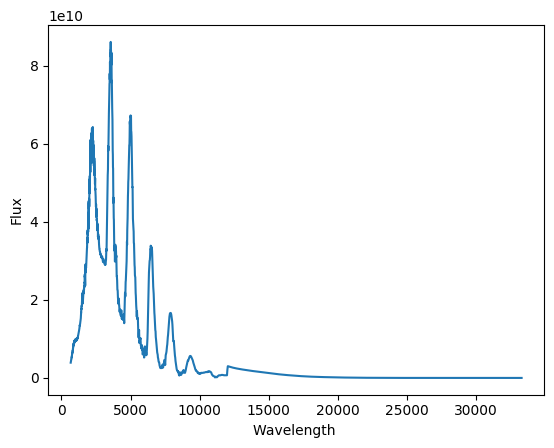

In [5]:
import pandas as pd
import matplotlib.pyplot as plt
import astropy.units as u
from picaso import justdoit as jdip

# ==== Convert temperature structure to PICASO format
planet_mass = 1  # in Jupiter mass
planet_radius = 1  # in Jupiter radius
d = {
    'pressure': pressures,
    'temperature': temperatures
}

# ==== Convert chemistry to PICASO format
chem_list = ['H2', 'H', 'VO', 'TiO', 'CO2', 'He', 'H2O', 'CH4', 'CO']
chem = {}
for n, name in enumerate(chem_list):
    d[name] = tp_profile[:, 4+n]

# ==== save everything as a pandas frame
df = pd.DataFrame(data=d)

# ==== Create PICASO class and set it up
opa = jdip.opannection(wave_range=[0.1, 20])
case1 = jdip.inputs(calculation='browndwarf')
case1.phase_angle(0)
case1.gravity(
    mass=planet_mass, mass_unit=u.Unit('M_jup'),
    radius=planet_radius, radius_unit=u.Unit('R_jup')
)

# ==== Add clouds and atmospheric structure
case1.atmosphere(df=df)
case1.clouds(df=df_cloud)

# ==== Calculate emission spectra
e_df = case1.spectrum(opa, full_output=True, calculation='thermal')

# ==== Regrid output
emis_wavn, _, emis_fp = e_df['wavenumber'], e_df['fpfs_thermal'], e_df['thermal']
emis_wavn_bin, emis_fp_bin = jdip.mean_regrid(emis_wavn, emis_fp, R=400)

# ==== plot the specturm
plt.figure()
plt.plot(emis_wavn_bin, emis_fp_bin)
plt.xlabel(r'Wavelength ')
plt.ylabel(r'Flux')
plt.show()
